# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, we will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement

**For this project, we would like to look at whether there are specific times of day where car accidents are more likely to occur. We have taken data from two datasets from Kaggle for this project:**

https://www.kaggle.com/datasets/jacksondivakarr/car-crash-dataset
https://www.kaggle.com/datasets/oktayrdeki/traffic-accidents

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**: Traffic Accidents

Type: CSV file.

Method: This data was downloaded manually from Kaggle using the "Download files" method.

Dataset variables:

`crash_date`: Date and time of the crash  

`traffic_control_device`: What sort of traffic signal was present

`weather_condition`: Weather at the time of the crash  

`lighting_condition`: Light conditions when the crash occurred 

`first_crash_type`: What type of crash it was  

`trafficway_type`: Type of road where the crash occurred  

`alignment`: Shape of the road at the crash location  

`roadway_surface_cond`: Condition of the road surface  

`road_defect`: Road problems that may have contributed  

`crash_type`: General type of crash  

`intersection_related_i`: Whether the crash happened at an intersection  

`damage`: Estimated property damage  

`prim_contributory_cause`: Main reason the crash occurred  

`num_units`: Number of vehicles involved  

`most_severe_injury`: Worst injury reported  

`injuries_total`: Total number of injuries  

`injuries_fatal`: Number of deaths  

`injuries_incapacitating`: Serious injuries preventing normal activity  

`injuries_non_incapacitating`: Minor injuries  

`injuries_reported_not_evident`: Reported injuries with no visible signs  

`injuries_no_indication`: People with no reported injury  

`crash_hour`: Hour of the day the crash occurred  

`crash_day_of_week`: Day of the week the crash occurred  

`crash_month`: Month when the crash occurred  

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

We used the "Download files manually" method for this source, and it has been placed directly into the workspace. This dataset is our largest one, and it contains detailed information on various traffic incidents, including the crash_hour, which will be very helpful in analyzing our research question.

In [77]:
d1 = pd.read_csv("traffic_accidents.csv")

#### Dataset 2: Monroe County Traffic Accidents

Type: CSV file.

Method: This dataset was gathered from the module `kagglehub` using the "Programatically downloading files method", with `kagglehub.dataset_download`.

Dataset variables:

`Year`: The year the crash happened.

`Month`: The month the crash happened.

`Day`: The day the crash happened.

`Weekend?`: Whether the crash happened on a weekend or not.

`Hour`: What hour the crash happened in.

`Collision Type`: How many cars were involved in the accident.

`Injury Type`: The type of injury in the accident.

`Primary Factor`: The primary cause of the crash.

`Reported_Location`: An address nearest to the crash site.

`Latitude`: The latitude of the crash site.

`Longitude`: The longitude of the crash site.

For our second database, we will programatically download the files. This dataset is helpful because it gives us data only on Monroe County crashes in New York, with timestamps, so we can analyze our question further in a more localized environment.

In [78]:
#If you do not have kagglehub, you can run pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("jacksondivakarr/car-crash-dataset")

In [79]:
d2 = pd.read_csv(f"{path}/monroe county car crach 2003-2015.csv", encoding="latin1")

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

First, let's take a look at our datasets for various quality issues.

In [80]:
#Inspecting our datasets visually
d1.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [81]:
d2.head()

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625


So far, there are no obvious quality issues, but let's take a programmatic look at the dataset to find potential quality issues.

In [82]:
#Inspecting the dataframe programmatically
d1.describe()

,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


In [83]:
d2.describe()

,Year,Month,Day,Hour,Latitude,Longitude
count,53943.000000,53943.000000,53943.000000,53718.000000,53913.000000,53913.000000
mean,2008.968059,6.662162,4.196912,1347.265349,35.582109,-78.619224
std,3.789760,3.514630,1.909440,531.654039,11.289883,24.957587
min,2003.000000,1.000000,1.000000,0.000000,0.000000,-88.959213
25%,2006.000000,4.000000,3.000000,1000.000000,39.142048,-86.551520
50%,2009.000000,7.000000,4.000000,1400.000000,39.164430,-86.530992
75%,2012.000000,10.000000,6.000000,1700.000000,39.173344,-86.508288
max,2015.000000,12.000000,7.000000,2300.000000,41.228665,86.596363


Interesting! It appears that we do see a quality issue here: One of the columns in our second dataset (Hour) is missing values in a little over 200 rows.

**Issue and Justification:** Our second dataset is missing values in the Hour column. These missing values would return null if we were to access the rows where the value is missing, which could cause errors in our data analysis. Thus, we should add a placeholder value to the rows where Hour is missing.

### Quality Issue 2:

Let's look for another quality issue by inspecting the data visually again. The distribution of latitude and longitude in our dataset looks especially suspicious.

<Axes: >

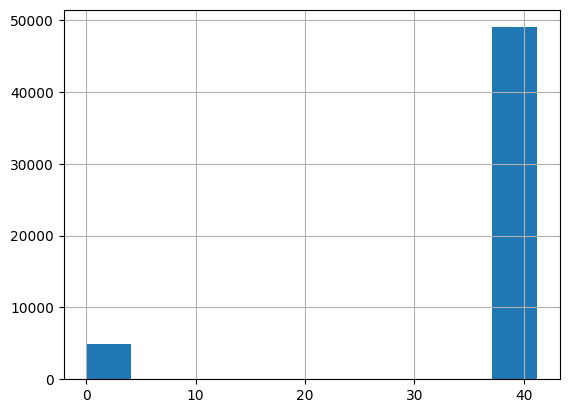

In [84]:
#Inspecting the dataframe visually
d2['Latitude'].hist()

<Axes: >

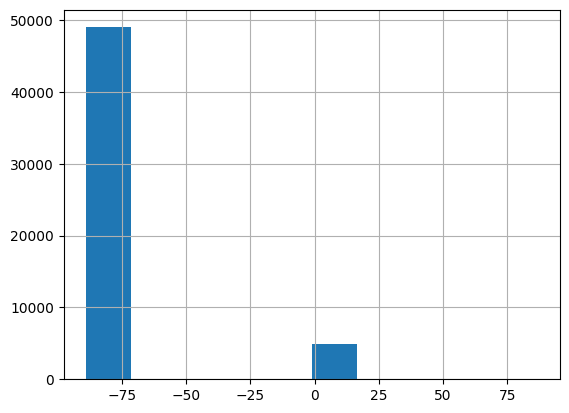

In [85]:
d2['Longitude'].hist()

Interesting! It looks like there are weird outliers in our latitude and longitude within this dataset. Let's try to break it down further and find the source of this.

In [86]:
#Inspecting the dataframe programmatically
d2['Latitude'].value_counts()

Latitude
0.000000     4908
39.164240    1424
39.164640     954
39.166640     622
39.164448     427
             ... 
39.033736       1
39.034595       1
39.034957       1
39.036716       1
39.126790       1
Name: count, Length: 15370, dtype: int64

In [87]:
d2['Longitude'].value_counts()

Longitude
 0.000000     4908
-86.533600     867
-86.532400     525
-86.538592     358
-86.534784     332
              ... 
-86.559073       1
-86.534734       1
-86.527020       1
-86.539700       1
-86.510897       1
Name: count, Length: 16068, dtype: int64

Ah ha! Now we can see what is going on - it looks like Lat/Long data was set to `0.000000` in cases where it was not recorded. We will need to also fix this in the next step, because it could dramatically skew our data and give us a mean that is completely inaccurate!

**Issue and Justification:** Almost 5000 records were assigned a blank latitude/longitude, which could dramatically skew the statistics of our latitude/longitude. Without fixing this, we could mistakenly assume that the majority of the records were in a completely different place! 

### Tidiness Issue 1:

Let's start our search for tidiness issues by checking out the data structure visually again.

In [88]:
#Inspecting the dataframe visually
d1.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [89]:
d2.head()

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625


Our second database has the time in the format we want (Year, Month, Day, Hour), but our first dataset has it in a single timestamp. Let's investigate this further.

In [90]:
#Inspecting the dataframe programmatically
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [91]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               53943 non-null  int64  
 1   Month              53943 non-null  int64  
 2   Day                53943 non-null  int64  
 3   Weekend?           53875 non-null  object 
 4   Hour               53718 non-null  float64
 5   Collision Type     53937 non-null  object 
 6   Injury Type        53943 non-null  object 
 7   Primary Factor     52822 non-null  object 
 8   Reported_Location  53908 non-null  object 
 9   Latitude           53913 non-null  float64
 10  Longitude          53913 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 4.5+ MB


It looks like we will need to use the data in `crash_date` to create 4 new columns, with `Hour` in `float64`, and `Year`, `Month`, and `Day` in `int64`.

**Issue and Justification:** Currently, our two datasets have the crash date in two very different formats, which will make analysis very difficult or impossible with rectification. To solve this, we will use the information in the crash_date column to create new columns.

### Tidiness Issue 2: 

Again, let's make another visual inspection of the dataframe.

In [92]:
#Inspecting the dataframe visually
d1.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [93]:
d2.head()

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625


In the second dataset, we have a column labelled `Collision Type`, which has the number of cars but in a text format. This is less than ideal, because we can't do analysis on it, as it is not in a number form. Let's look programatically at what how our first dataset encodes this.

In [94]:
#Inspecting the dataframe programmatically
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [95]:
d1["num_units"].head()

0    2
1    2
2    3
3    2
4    2
Name: num_units, dtype: int64

It looks like the first dataset already has this in the correct form! So we will just need to convert the second dataset's information into this format.

**Issue and Justification:** The issue is that our second dataset uses an `object` datatype in order to store the number of cars involved in a crash. This is problematic because we can't do numeric analysis on this data, so we will convert it to an `int64` dtype.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

First, we will make copies of the datasets to ensure that the raw dataframes are not impacted.

In [96]:
d1_clean = d1.copy()
d2_clean = d2.copy()

### **Quality Issue 1: Fix Missing `Hour` Values in Dataset 2**

In [97]:
d2_clean["Hour"] = d2_clean["Hour"].fillna(1400.0)

In [98]:
# Now we can convert the dtype to int64, since there are no null values!
d2_clean["Hour"] = d2_clean["Hour"].astype("int64")

In [99]:
# Let's make sure the cleaning was successful
d2_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               53943 non-null  int64  
 1   Month              53943 non-null  int64  
 2   Day                53943 non-null  int64  
 3   Weekend?           53875 non-null  object 
 4   Hour               53943 non-null  int64  
 5   Collision Type     53937 non-null  object 
 6   Injury Type        53943 non-null  object 
 7   Primary Factor     52822 non-null  object 
 8   Reported_Location  53908 non-null  object 
 9   Latitude           53913 non-null  float64
 10  Longitude          53913 non-null  float64
dtypes: float64(2), int64(4), object(5)
memory usage: 4.5+ MB


Justification: We have filled in the missing `Hour` values with the median of the Hour column, in order to make sure that our statistics are not skewed. The cleaning has been successful, as there are now no null values in the `Hour` column, as the `Non-Null` values match the number of entries in the database.

### **Quality Issue 2: Replace `0` Latitude/Longitude values with a realistic value.**

In [100]:
# First, let's get the mode of the Latitude/Longitude columns so that we can use it as a replacement value.
print(d2_clean["Latitude"].mode())
print(d2_clean["Longitude"].mode())

0    0.0
Name: Latitude, dtype: float64
0    0.0
Name: Longitude, dtype: float64


In [101]:
# Unfortunately, the most common value is the placeholder `0`, so we will need to go for the second most common value.
print(d2_clean["Latitude"].value_counts())
print(d2_clean["Longitude"].value_counts())

Latitude
0.000000     4908
39.164240    1424
39.164640     954
39.166640     622
39.164448     427
             ... 
39.033736       1
39.034595       1
39.034957       1
39.036716       1
39.126790       1
Name: count, Length: 15370, dtype: int64
Longitude
 0.000000     4908
-86.533600     867
-86.532400     525
-86.538592     358
-86.534784     332
              ... 
-86.559073       1
-86.534734       1
-86.527020       1
-86.539700       1
-86.510897       1
Name: count, Length: 16068, dtype: int64


In [102]:
# Now that we have our values, let's fix the 0's with the most common non-zero value.
d2_clean["Latitude"] = d2_clean["Latitude"].replace(0, 39.164240)
d2_clean["Longitude"] = d2_clean["Longitude"].replace(0, -86.533600)

In [103]:
# Let's make sure the cleaning was successful
print(d2_clean["Latitude"].value_counts())
print(d2_clean["Longitude"].value_counts())

Latitude
39.164240    6332
39.164640     954
39.166640     622
39.164448     427
39.165648     324
             ... 
39.016029       1
39.017549       1
39.019930       1
39.020321       1
39.023732       1
Name: count, Length: 15369, dtype: int64
Longitude
-86.533600    5775
-86.532400     525
-86.538592     358
-86.534784     332
-86.534768     288
              ... 
-86.559073       1
-86.534734       1
-86.527020       1
-86.539700       1
-86.510897       1
Name: count, Length: 16067, dtype: int64


Justification: In this case, because the mean *and* medians may skew the dataset (because there are many more accidents in a certain coordinate range than in others), we have used the mode for replacing these values. While this may not be a perfect solution, it is the best we can do in this case, because we have so much missing data, and ensures that we do not have so many outliers in the `Latitude` and `Longitude` columns.

### **Tidiness Issue 1: Creating new columns for Year, Month, Day, and Hour in Dataset 1**

In [104]:
# First, we will find a way to break down our timestamp into multiple columns.
# Let's convert to datetime first, so we can break it down further.
d1_clean["crash_date"] = pd.to_datetime(d1_clean["crash_date"])

/tmp/ipykernel_310230/2394684370.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d1_clean["crash_date"] = pd.to_datetime(d1_clean["crash_date"])


In [105]:
# Now we can create the new columns
d1_clean["Year"] = d1_clean["crash_date"].dt.year
d1_clean["Month"] = d1_clean["crash_date"].dt.month
d1_clean["Day"] = d1_clean["crash_date"].dt.day
d1_clean["Hour"] = d1_clean["crash_date"].dt.hour

In [106]:
#Validate the cleaning was successful
d1_clean[["crash_date", "Year", "Month", "Day", "Hour"]].head()

,crash_date,Year,Month,Day,Hour
0,2023-07-29 13:00:00,2023,7,29,13
1,2023-08-13 00:11:00,2023,8,13,0
2,2021-12-09 10:30:00,2021,12,9,10
3,2023-08-09 19:55:00,2023,8,9,19
4,2023-08-19 14:55:00,2023,8,19,14


Justification: This will make it easier for us to analyze if there is any connection between crashes and what hour it is, and allow us to combine the datasets later on.

### **Tidiness Issue 2: Making `Collision Type` in Dataset 2 more like `num_units` in Dataset 1**

In [107]:
# Let's take a look at Collision Type again to see if there's anything we may need to update.
d2_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               53943 non-null  int64  
 1   Month              53943 non-null  int64  
 2   Day                53943 non-null  int64  
 3   Weekend?           53875 non-null  object 
 4   Hour               53943 non-null  int64  
 5   Collision Type     53937 non-null  object 
 6   Injury Type        53943 non-null  object 
 7   Primary Factor     52822 non-null  object 
 8   Reported_Location  53908 non-null  object 
 9   Latitude           53913 non-null  float64
 10  Longitude          53913 non-null  float64
dtypes: float64(2), int64(4), object(5)
memory usage: 4.5+ MB


In [108]:
# Ah ha! There are null values in the Collision Type column. Let's update these to the most common value, a 2-Car accident.
d2_clean["Collision Type"] = d2_clean["Collision Type"].fillna("2-Car")

In [109]:
d2_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               53943 non-null  int64  
 1   Month              53943 non-null  int64  
 2   Day                53943 non-null  int64  
 3   Weekend?           53875 non-null  object 
 4   Hour               53943 non-null  int64  
 5   Collision Type     53943 non-null  object 
 6   Injury Type        53943 non-null  object 
 7   Primary Factor     52822 non-null  object 
 8   Reported_Location  53908 non-null  object 
 9   Latitude           53913 non-null  float64
 10  Longitude          53913 non-null  float64
dtypes: float64(2), int64(4), object(5)
memory usage: 4.5+ MB


In [110]:
#Now let's create a new column to be like the num_units column in Dataset 1.
d2_clean["num_units"] = d2_clean["Collision Type"].str.extract(r"(\d+)")[0].astype("Int64")

In [111]:
#Validate the cleaning was successful
d2_clean.head()

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude,num_units
0,2015,1,5,Weekday,0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874,2
1,2015,1,6,Weekday,1500,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848,2
2,2015,1,6,Weekend,2300,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890,2
3,2015,1,7,Weekend,900,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956,2
4,2015,1,7,Weekend,1100,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625,2


As you can see above, now we have a new column called `num_units` that matches the format as our first dataset.

Justification: Before, the `Collision Type` column in Dataset 2 had an incompatible data type for doing numeric analysis, so we have added a new column that matches what we have in Dataset 1. Now that this is fixed, we can go ahead and combine the datasets and do analysis!

### **Remove unnecessary variables and combine datasets**

Next, we will create a combined dataset so that we can analyze the data from a single source.

In [112]:
#Combine datasets
combined = d1_clean.merge(d2_clean, on=["Year", "Month", "Day", "Hour", "num_units"], how="left", suffixes=("_d1", "_d2"))

In [113]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209307 entries, 0 to 209306
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   crash_date                     209307 non-null  datetime64[ns]
 1   traffic_control_device         209307 non-null  object        
 2   weather_condition              209307 non-null  object        
 3   lighting_condition             209307 non-null  object        
 4   first_crash_type               209307 non-null  object        
 5   trafficway_type                209307 non-null  object        
 6   alignment                      209307 non-null  object        
 7   roadway_surface_cond           209307 non-null  object        
 8   road_defect                    209307 non-null  object        
 9   crash_type                     209307 non-null  object        
 10  intersection_related_i         209307 non-null  object        
 11  

In [114]:
# Let's take a look at how the data looks now.
combined.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,Month,Day,Hour,Weekend?,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2023-07-29 13:00:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,7,29,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-08-13 00:11:00,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,8,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-12-09 10:30:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,12,9,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-08-09 19:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,8,9,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-08-19 14:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,8,19,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
combined.tail()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,Month,Day,Hour,Weekend?,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
209302,2023-09-13 13:08:00,UNKNOWN,UNKNOWN,UNKNOWN,TURNING,FOUR WAY,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,9,13,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209303,2023-07-18 14:10:00,UNKNOWN,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,7,18,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209304,2019-10-23 13:32:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,PEDESTRIAN,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT ON GRADE,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,10,23,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209305,2020-06-01 15:23:00,NO CONTROLS,CLEAR,DAYLIGHT,PEDESTRIAN,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,6,1,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209306,2022-12-16 12:10:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,FOUR WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,NO INJURY / DRIVE AWAY,...,12,16,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As you can see, there are some NaN values, but this is fine for the purpose of our analysis since we won't be using these variables.

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [116]:
# This will create the new files in the directory where your Jupyter Notebook is.
d1_clean.to_csv('traffic_accidents_cleaned.csv', index=False, encoding="utf-8")
d2_clean.to_csv('monroe_county_accidents_cleaned.csv', index=False, encoding="utf-8")
combined.to_csv('accidents_combined.csv', index=False, encoding="utf-8")

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

***Research question:* Are there specific times of day where car accidents are more likely to occur?**

In [117]:
# First, let's see if there is anything interesting in the statistics!
combined["Hour"].describe()

count    209307.000000
mean         13.372983
std           5.603893
min           0.000000
25%           9.000000
50%          14.000000
75%          17.000000
max          23.000000
Name: Hour, dtype: float64

It looks like the data is showing that more accidents happen after noon than before, but let's use a histogram to investigate further.

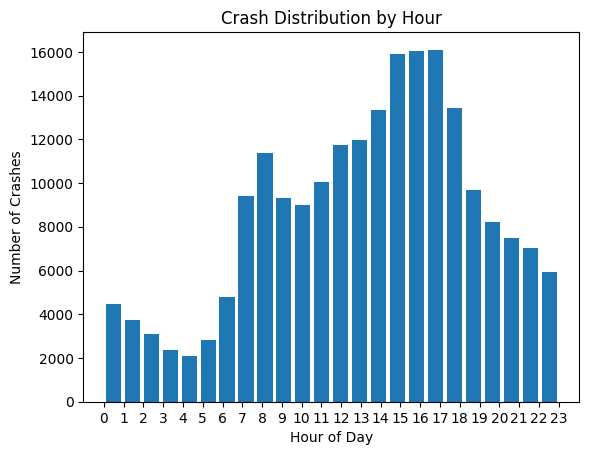

In [118]:
#Let's create a basic histogram to see if particular hours of the day are associated with higher numbers of accidents.
combined["Hour"].plot.hist(
    bins=24,
    rwidth=0.8,
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.title("Crash Distribution by Hour")
plt.xticks(range(0, 24))
plt.show()

Interesting! It does appear that accidents are the most common from 3:00-5:00PM. This makes sense, since this is usually the time of rush-hour traffic in most cities!

**Answer to research question:** Based on the data, accidents are most commonly observed from 3:00-5:00PM, and there are slightly more accidents after noon than before.

Let's investigate this further with another visual, now using the month .

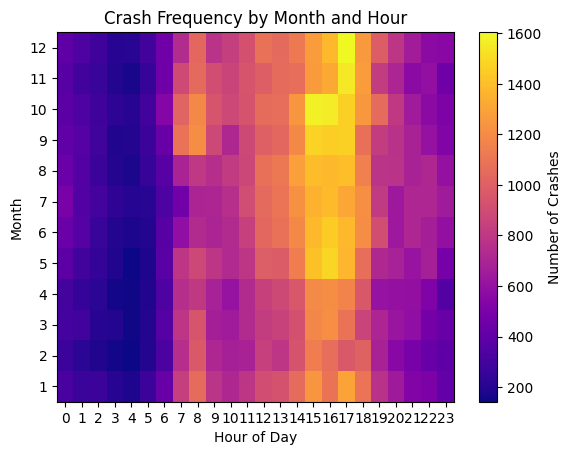

In [120]:
# Let's create a heatmap so that we can see if the month has anything to do with crashes by hour.
heatmap_data = combined.pivot_table(
    index="Month", 
    columns="Hour", 
    aggfunc="size",
    fill_value=0
)

heatmap_array = heatmap_data.values
plt.imshow(heatmap_array, aspect='auto', cmap='plasma', origin='lower')
plt.colorbar(label='Number of Crashes')
plt.xlabel('Hour of Day')
plt.ylabel('Month')
plt.title('Crash Frequency by Month and Hour')
plt.xticks(ticks=np.arange(0,24), labels=np.arange(0,24))
plt.yticks(ticks=np.arange(0,12), labels=np.arange(1,13))
plt.show()

Wow! How interesting. It appears as though the beginning months of the year are far more mild, crash-wise, than near the end of the year, but crashes still appear to be consistently higher throughout the months between 3:00PM and 5:00PM!

*Answer to research question:* We still see a strong correlation between higher crashes and times between 3:00PM and 5:00PM, but interestingly, it appears that there are more crashes within these hours in the months of May-October. Overall, this visualization has strengthened our theory from the previous visualization we made.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* I would definitely want to clean the datasets more. We left multiple quality issues untouched that exist in Dataset 2, and in Dataset 1, there are multiple tidiness issues that could be resolved. I'd also like to explore the data more to understand why accidents happen more often between 3:00PM and 5:00PM, and why they happen more often within certain months, or if there is some association with fatal accidents.